## Outliers

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
arr1 = np.random.randint(20,60,size=(20))
arr1

array([25, 53, 48, 52, 21, 48, 58, 58, 57, 33, 20, 59, 52, 45, 22, 42, 44,
       39, 38, 48])

In [3]:
arr2 = np.array([35, 29, 49, 34, 38, 35, 53, 50, 53, 25, 47, 36, 26, 29, 49, 31, 33, 42, 245, 260])
arr2

array([ 35,  29,  49,  34,  38,  35,  53,  50,  53,  25,  47,  36,  26,
        29,  49,  31,  33,  42, 245, 260])

<Axes: ylabel='Density'>

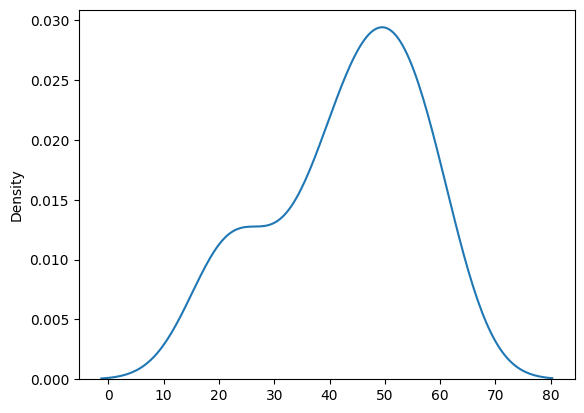

In [4]:
sns.kdeplot(arr1)

<Axes: ylabel='Density'>

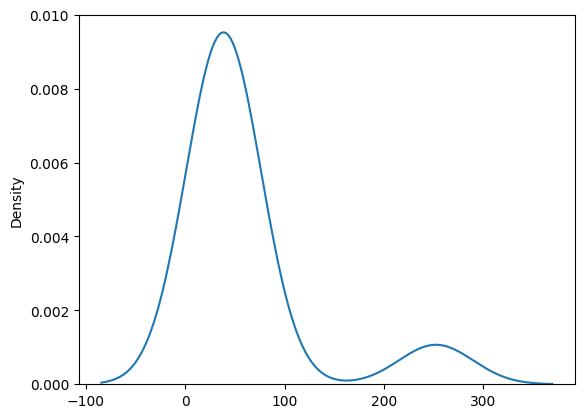

In [5]:
sns.kdeplot(arr2)

<Axes: >

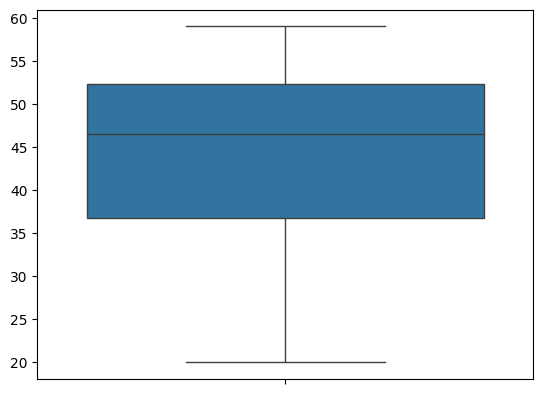

In [6]:
sns.boxplot(arr1)

<Axes: >

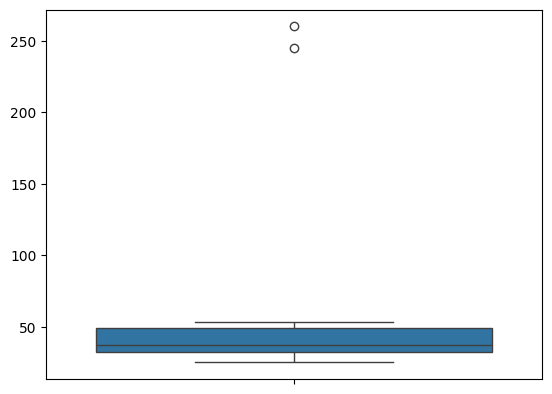

In [7]:
sns.boxplot(arr2)

In [8]:
from scipy.stats import skew, kurtosis

In [9]:
skew(arr1)

-0.593461237243447

In [10]:
skew(arr2)

2.584298426012599

## 1. Z-score Method

When data distribution is normal
Most of the values lies around mean
std >> how far away a datapoint is from mean
z_Score >> how many std away a datapoint is from mean

Outlier Treatment:
    1. Trimming(drop)
    2. Capping (Impuation)

# Standardization

z_score = (X-X_mean)/std
x >> datapoint
x_mean >> mean values
std >> standard deviation

In [11]:
print(arr1)
mean = np.mean(arr1)
print(f'Mean == {mean}')

std = np.std(arr1)
print(f'Std == {std}')

[25 53 48 52 21 48 58 58 57 33 20 59 52 45 22 42 44 39 38 48]
Mean == 43.1
Std == 12.577360613419653


In [12]:
x = 45
z_score_x = (x - mean)/std
z_score_x

0.15106508101332147

In [13]:
x = 21
z_score_x = (x - mean)/std
z_score_x

-1.7571254159970564

In [14]:
x = 250
z_score_x = (x - mean)/std
z_score_x

16.450192242976968

In [15]:
print(arr1)
mean = np.mean(arr1)
print(f'Mean == {mean}')

std = np.std(arr1)
print(f'Std == {std}')

threshold = 3
outliers_list = []

for x_val in arr1:
    z_score = (x_val-mean)/std
    z_score = np.abs(z_score)
    print(f'{x_val} >> {z_score}')
    
    if z_score > threshold:
        outliers_list.append(x_val)
        
print('Outliers are :', outliers_list)

[25 53 48 52 21 48 58 58 57 33 20 59 52 45 22 42 44 39 38 48]
Mean == 43.1
Std == 12.577360613419653
25 >> 1.4390936664953269
53 >> 0.7871285800167808
48 >> 0.3895888931396187
52 >> 0.7076206426413484
21 >> 1.7571254159970564
48 >> 0.3895888931396187
58 >> 1.1846682668939428
58 >> 1.1846682668939428
57 >> 1.1051603295185104
33 >> 0.8030301674918675
20 >> 1.8366333533724888
59 >> 1.2641762042693752
52 >> 0.7076206426413484
45 >> 0.15106508101332147
22 >> 1.677617478621624
42 >> 0.08745873111297577
44 >> 0.07155714363788906
39 >> 0.325982543239273
38 >> 0.40549048061470544
48 >> 0.3895888931396187
Outliers are : []


In [16]:
print(arr2)
mean = np.mean(arr2)
print(f'Mean == {mean}')

std = np.std(arr2)
print(f'Std == {std}')

threshold = 3
outliers_list = []

for x_val in arr2:
    z_score = (x_val-mean)/std
    z_score = np.abs(z_score)
    print(f'{x_val} >> {z_score}')
    
    if z_score > threshold:
        outliers_list.append(x_val)
        
print('Outliers are :', outliers_list)

[ 35  29  49  34  38  35  53  50  53  25  47  36  26  29  49  31  33  42
 245 260]
Mean == 59.95
Std == 64.81394525871728
35 >> 0.384948021608734
29 >> 0.47752069213588444
49 >> 0.16894512371204962
34 >> 0.40037680002992576
38 >> 0.33866168634515875
35 >> 0.384948021608734
53 >> 0.10723001002728265
50 >> 0.15351634529085786
53 >> 0.10723001002728265
25 >> 0.5392358058206514
47 >> 0.1998026805544331
36 >> 0.36951924318754226
26 >> 0.5238070273994597
29 >> 0.47752069213588444
49 >> 0.16894512371204962
31 >> 0.44666313529350093
33 >> 0.4158055784511175
42 >> 0.2769465726603918
245 >> 2.855095446841532
260 >> 3.0865271231594082
Outliers are : [260]


29 = 59.95 - z * (64.81)
z = (29-59.95)/64.81

In [25]:
(29-59.95)/64.81

-0.47754976083937667

In [26]:
(245 -59.95)/64.81

2.855269248572751

In [17]:
print(arr2)
mean = np.mean(arr2)
print(f'Mean == {mean}')

std = np.std(arr2)
print(f'Std == {std}')

threshold = 2
outliers_list = []

for x_val in arr2:
    z_score = (x_val-mean)/std
    z_score = np.abs(z_score)
    print(f'{x_val} >> {z_score}')
    
    if z_score > threshold:
        outliers_list.append(x_val)
        
print('Outliers are :', outliers_list)

[ 35  29  49  34  38  35  53  50  53  25  47  36  26  29  49  31  33  42
 245 260]
Mean == 59.95
Std == 64.81394525871728
35 >> 0.384948021608734
29 >> 0.47752069213588444
49 >> 0.16894512371204962
34 >> 0.40037680002992576
38 >> 0.33866168634515875
35 >> 0.384948021608734
53 >> 0.10723001002728265
50 >> 0.15351634529085786
53 >> 0.10723001002728265
25 >> 0.5392358058206514
47 >> 0.1998026805544331
36 >> 0.36951924318754226
26 >> 0.5238070273994597
29 >> 0.47752069213588444
49 >> 0.16894512371204962
31 >> 0.44666313529350093
33 >> 0.4158055784511175
42 >> 0.2769465726603918
245 >> 2.855095446841532
260 >> 3.0865271231594082
Outliers are : [245, 260]


In [18]:
df = pd.read_csv('diabetes.csv')
df

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,50,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,52,1
3,150,66,23,94,28.1,0.167,21,0
4,150,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,101,76,48,180,32.9,0.171,63,0
764,122,70,27,0,36.8,0.340,27,0
765,121,72,23,112,26.2,0.245,30,0
766,126,60,0,0,30.1,0.349,47,1


<Axes: >

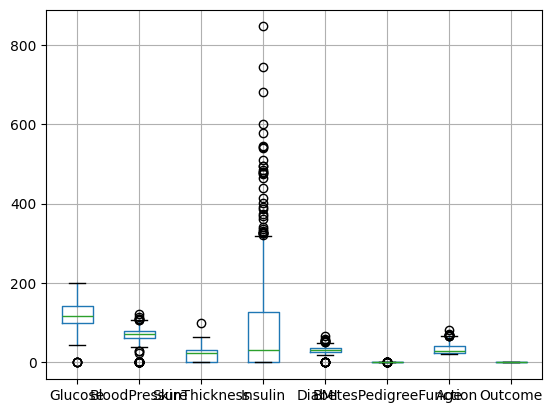

In [19]:
df.boxplot()

<Axes: xlabel='Insulin', ylabel='Density'>

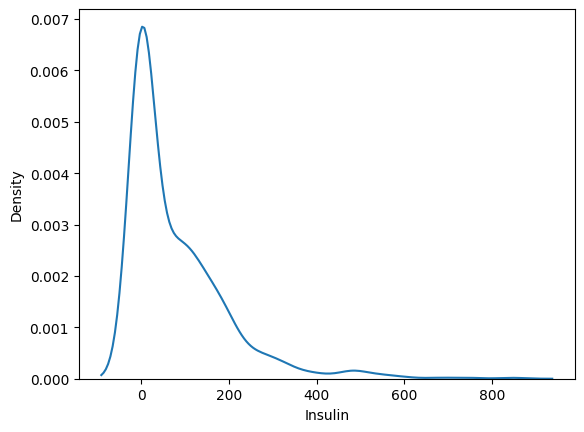

In [22]:
sns.kdeplot(df['Insulin'])

In [20]:
def get_outliers(feature):
    
    mean = feature.mean()
    print(f'Mean == {mean}')
    
    std = feature.std()
    print(f'Std == {std}')
    
    threshold = 3
    outliers_list = []

    for x_val in feature.values:
        z_score = (x_val-mean)/std
        z_score = np.abs(z_score)

        if z_score > threshold:
            print(f'{x_val} >> {z_score}')
            outliers_list.append(x_val)

    
get_outliers(df['Insulin'])

Mean == 79.79947916666667
Std == 115.24400235133837
543 >> 4.019302622111284
846 >> 6.648506691892372
495 >> 3.602795046700419
485 >> 3.5160226351564887
495 >> 3.602795046700419
478 >> 3.4552819470757377
744 >> 5.763428094144283
680 >> 5.20808466026313
545 >> 4.036657104420071
465 >> 3.3424778120686285
579 >> 4.3316833036694335
474 >> 3.4205729824581654
480 >> 3.4726364293845235
600 >> 4.513905367911687
440 >> 3.1255467832088026
540 >> 3.993270898648105
480 >> 3.4726364293845235
510 >> 3.7329536640163146


In [26]:
import scipy.stats as ss
# from statsmodels.stats.ou
# print(dir(ss))

In [23]:
from scipy.stats import zscore

def get_outliers(feature):
    
    threshold = 3
    outliers_list = []
    
    z_score = zscore(feature)
    outliers_index = np.where(np.abs(z_score) > threshold)[0]
    print(outliers_index)
    
    print(feature.iloc[outliers_index])
    
get_outliers(df['Insulin'])

[  8  13 111 153 186 220 228 247 286 370 409 415 486 584 645 655 695 753]
8      543
13     846
111    495
153    485
186    495
220    478
228    744
247    680
286    545
370    465
409    579
415    474
486    480
584    600
645    440
655    540
695    480
753    510
Name: Insulin, dtype: int64


## 2. IQR (Inter Quartile Range)

Use when the data is not normally distributed

Boxplot:
    Median (50%ile/Q2):
        the middle value of the  dataset
        
    1st Quartile (Q1/25%ile):
        middle no between min and median
        
    3rd Quartile (Q3, 75%ile):
        middle no between median and max
        
IQR : 
    25% to 75%
    
    maximum = Q3 + 1.5 *IQR
    minimum = Q1 - 1.5 *IQR

In [24]:
df.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.117188,69.076823,20.536458,79.799479,31.992578,0.471876,33.243490,0.348958
std,31.805091,19.367794,15.952218,115.244002,7.884160,0.331329,11.758182,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,142.000000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: xlabel='Insulin', ylabel='Density'>

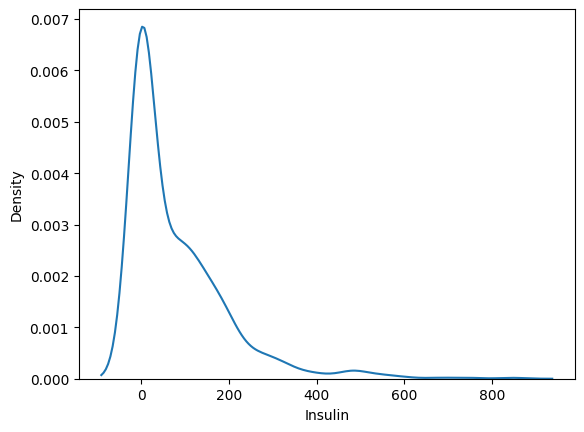

In [25]:
sns.kdeplot(df['Insulin'])

<Axes: xlabel='Insulin', ylabel='Count'>

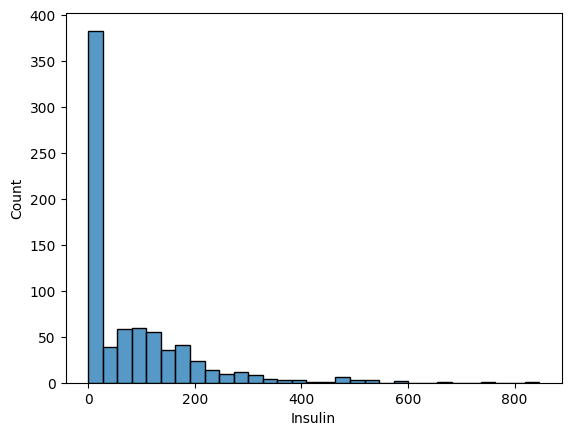

In [26]:
sns.histplot(df['Insulin'])

In [27]:
df['Glucose'].median()

117.0

In [28]:
df['Glucose'].quantile(0.5)

117.0

In [29]:
q1 = df['Glucose'].quantile(0.25)
q2 = df['Glucose'].quantile(0.5)
q3 = df['Glucose'].quantile(0.75)

print('Q1 == ', q1)
print('Q2 == ', q2)
print('Q3 == ', q3)

iqr = q3 - q1
print('IQR == ', iqr)

upper_tail = q3 + 1.5* iqr
lower_tail = q1 - 1.5* iqr

print('Upper Tail == ', upper_tail)
print('Lower Tail == ', lower_tail)

Q1 ==  99.0
Q2 ==  117.0
Q3 ==  142.0
IQR ==  43.0
Upper Tail ==  206.5
Lower Tail ==  34.5


In [30]:
df[df['Glucose'] < lower_tail]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,0,48,20,0,24.7,0.140,22,0
182,0,74,20,23,27.7,0.299,21,0
342,0,68,35,0,32.0,0.389,22,0
349,0,80,32,0,41.0,0.346,37,1
502,0,68,41,0,39.0,0.727,41,1


In [31]:
df[df['Glucose'] > upper_tail]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


<Axes: ylabel='Glucose'>

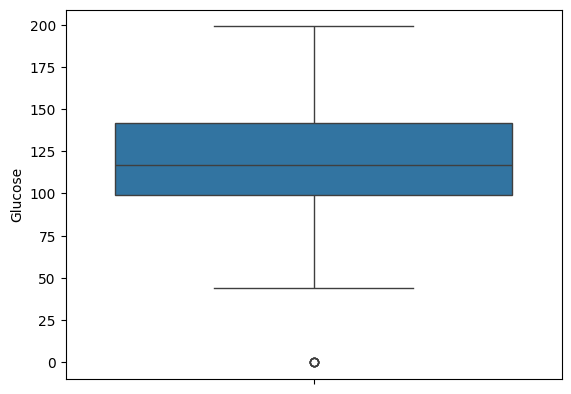

In [32]:
sns.boxplot(df['Glucose'])

In [33]:
df[(df['Glucose']< lower_tail) | (df['Glucose'] > upper_tail)]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,0,48,20,0,24.7,0.140,22,0
182,0,74,20,23,27.7,0.299,21,0
342,0,68,35,0,32.0,0.389,22,0
349,0,80,32,0,41.0,0.346,37,1
502,0,68,41,0,39.0,0.727,41,1


In [34]:
q1 = df['Insulin'].quantile(0.25)
q2 = df['Insulin'].quantile(0.5)
q3 = df['Insulin'].quantile(0.75)

print('Q1 == ', q1)
print('Q2 == ', q2)
print('Q3 == ', q3)

iqr = q3 - q1
print('IQR == ', iqr)

upper_tail = q3 + 1.5* iqr
lower_tail = q1 - 1.5* iqr

print('Upper Tail == ', upper_tail)
print('Lower Tail == ', lower_tail)

Q1 ==  0.0
Q2 ==  30.5
Q3 ==  127.25
IQR ==  127.25
Upper Tail ==  318.125
Lower Tail ==  -190.875


In [35]:
df[(df['Insulin']< lower_tail) | (df['Insulin'] > upper_tail)].shape

(34, 8)

In [36]:
titanic_df = pd.read_csv('titanic.csv')
titanic_df

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


<Axes: xlabel='Age', ylabel='Density'>

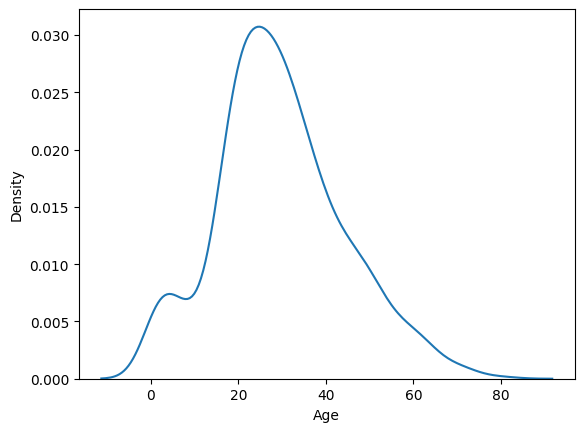

In [37]:
sns.kdeplot(titanic_df['Age'])

<Axes: ylabel='Age'>

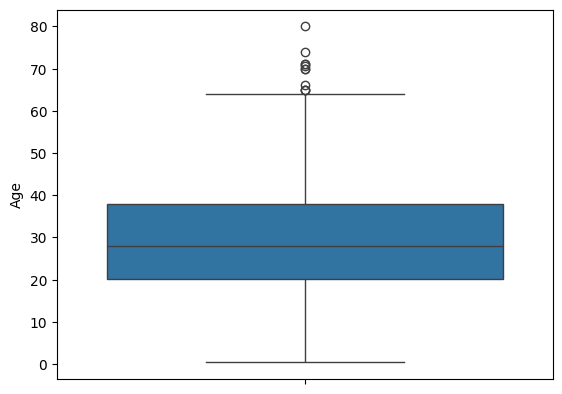

In [38]:
sns.boxplot(titanic_df['Age'])

<Axes: xlabel='Age', ylabel='Gender'>

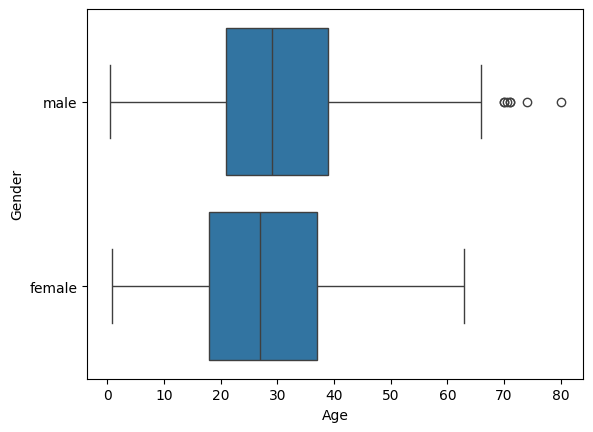

In [39]:
sns.boxplot(x = titanic_df['Age'], y = titanic_df['Gender'])

<Axes: xlabel='Survived', ylabel='Age'>

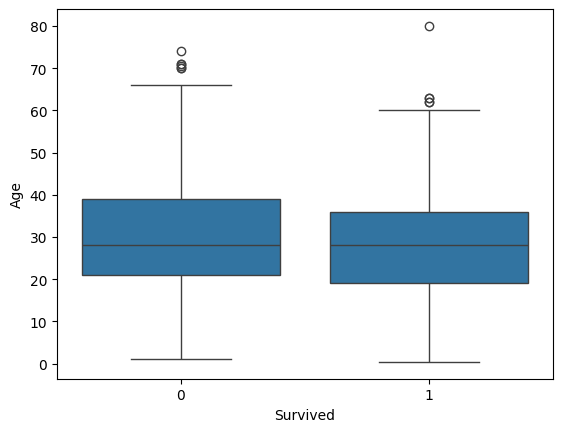

In [40]:
sns.boxplot(x = titanic_df['Survived'], y =  titanic_df['Age'])

In [13]:
titanic_df['Survived'].unique()

array([0, 1], dtype=int64)

<Axes: xlabel='Pclass', ylabel='Age'>

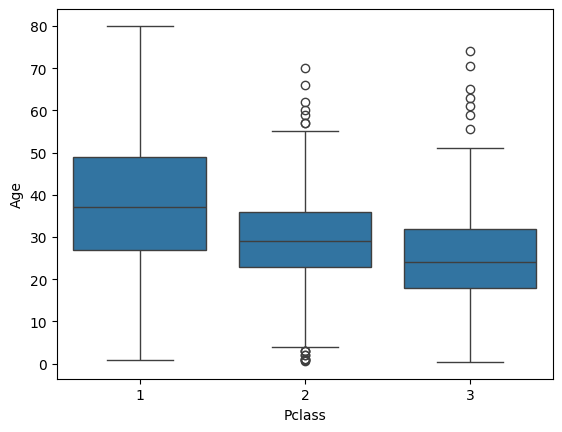

In [41]:
sns.boxplot(x = titanic_df['Pclass'], y =  titanic_df['Age'])

In [42]:
pd.crosstab(titanic_df['Survived'], titanic_df['Pclass'])

Pclass,1,2,3
Survived,,,
0,80,97,370
1,136,87,121


<Axes: xlabel='Age', ylabel='Glucose'>

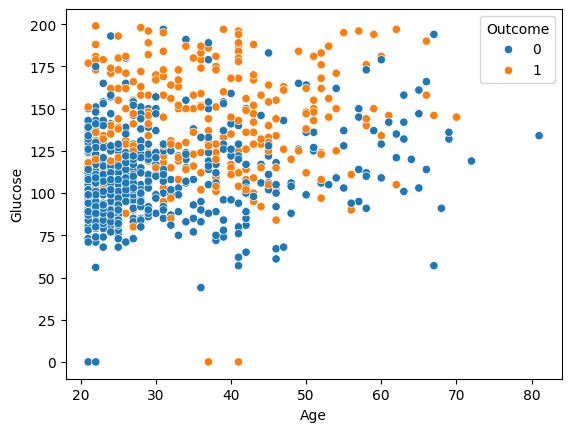

In [43]:
sns.scatterplot(x = df['Age'], y =df['Glucose'], hue = df['Outcome'])

In [44]:
ins_df = pd.read_csv('medical_insurance.csv').head(300)
ins_df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
295,18,male,22.990,0,no,northeast,1704.56810
296,19,male,27.700,0,yes,southwest,16297.84600
297,47,male,25.410,1,yes,southeast,21978.67690
298,31,male,34.390,3,yes,northwest,38746.35510


In [46]:
ins_df.groupby('smoker')[['charges']].mean()

,charges
smoker,
no,8139.738988
yes,31591.421895


In [47]:
ins_df.groupby('region')[['charges']].mean()

,charges
region,
northeast,14102.583403
northwest,12613.222849
southeast,14715.689519
southwest,13537.357665


In [48]:
ins_df.groupby('gender')[['charges']].mean()

,charges
gender,
female,12245.974934
male,15270.149673


In [49]:
ins_df.groupby('children')[['charges']].mean()

,charges
children,
0,13061.774827
1,12437.406379
2,15919.930266
3,16765.576655
4,9125.645210
5,5439.295000


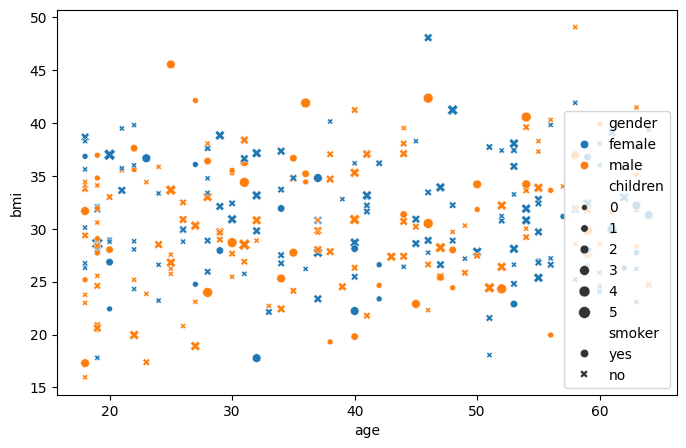

In [53]:
plt.figure(figsize=[8,5])
sns.scatterplot(x = ins_df['age'], y = ins_df['bmi'], hue = ins_df['gender'],
               style=ins_df['smoker'], size = ins_df['children'])
plt.legend()

### Handling of Outliers

1. Delete Observations
2. Imputations
3. Transformations

### Trimming(Delete)

In [54]:
def trim_outliers(feature):
    q1 = feature.quantile(0.25)
    q2 = feature.quantile(0.5)
    q3 = feature.quantile(0.75)
    
    print('Q1 == ', q1)
    print('Q2 == ', q2)
    print('Q3 == ', q3)
    
    iqr = q3 - q1
    print('IQR == ', iqr)
    
    upper_tail = q3 + 1.5* iqr
    lower_tail = q1 - 1.5* iqr
    
    print('Upper Tail == ', upper_tail)
    print('Lower Tail == ', lower_tail)

    indices = np.where((feature > upper_tail) | (feature < lower_tail))[0]
    print(indices)
    return indices

ins_outliers = trim_outliers(df['Insulin'])

Q1 ==  0.0
Q2 ==  30.5
Q3 ==  127.25
IQR ==  127.25
Upper Tail ==  318.125
Lower Tail ==  -190.875
[  8  13  54 111 139 153 186 220 228 231 247 248 258 286 296 360 370 375
 392 409 415 480 486 519 574 584 612 645 655 695 707 710 715 753]


In [55]:
ins_outliers

array([  8,  13,  54, 111, 139, 153, 186, 220, 228, 231, 247, 248, 258,
       286, 296, 360, 370, 375, 392, 409, 415, 480, 486, 519, 574, 584,
       612, 645, 655, 695, 707, 710, 715, 753], dtype=int64)

In [56]:
df1 = df.copy()
df1.shape

(768, 8)

In [57]:
df1.drop(ins_outliers).shape

(734, 8)

In [58]:
34/768

0.044270833333333336

<Axes: >

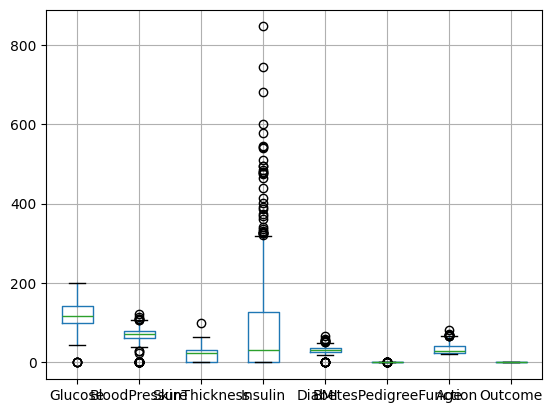

In [59]:
df.boxplot()

In [60]:
bp_outliers = trim_outliers(df['BloodPressure'])
df1.drop(bp_outliers).shape

Q1 ==  62.0
Q2 ==  72.0
Q3 ==  80.0
IQR ==  18.0
Upper Tail ==  107.0
Lower Tail ==  35.0
[  7  15  18  43  49  60  78  81  84 106 125 172 177 193 222 261 266 269
 300 332 336 347 357 362 426 430 435 453 468 484 494 522 533 535 549 589
 597 601 604 619 643 691 697 703 706]


(723, 8)

#### Extreme Outliers

In [40]:
q1 = df['Insulin'].quantile(0.25)
q2 = df['Insulin'].quantile(0.5)
q3 = df['Insulin'].quantile(0.75)

print('Q1 == ', q1)
print('Q2 == ', q2)
print('Q3 == ', q3)

iqr = q3 - q1
print('IQR == ', iqr)

upper_tail = q3 + 1.5* iqr
lower_tail = q1 - 1.5* iqr

print('Upper Tail == ', upper_tail)
print('Lower Tail == ', lower_tail)

Q1 ==  0.0
Q2 ==  30.5
Q3 ==  127.25
IQR ==  127.25
Upper Tail ==  318.125
Lower Tail ==  -190.875


In [41]:
df[(df['Insulin']< lower_tail) | (df['Insulin'] > upper_tail)].shape

(34, 8)

In [61]:
q1 = df['Insulin'].quantile(0.25)
q2 = df['Insulin'].quantile(0.5)
q3 = df['Insulin'].quantile(0.75)

print('Q1 == ', q1)
print('Q2 == ', q2)
print('Q3 == ', q3)

iqr = q3 - q1
print('IQR == ', iqr)

upper_tail = q3 + 3* iqr    # Extreme Outliers
lower_tail = q1 - 3* iqr

print('Upper Tail == ', upper_tail)
print('Lower Tail == ', lower_tail)

Q1 ==  0.0
Q2 ==  30.5
Q3 ==  127.25
IQR ==  127.25
Upper Tail ==  509.0
Lower Tail ==  -381.75


In [62]:
df[(df['Insulin']< lower_tail) | (df['Insulin'] > upper_tail)].shape

(9, 8)

In [63]:
df[(df['Insulin']< lower_tail) | (df['Insulin'] > upper_tail)]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
8,150,70,45,543,30.5,0.158,35,1
13,150,60,23,846,30.1,0.398,59,1
228,197,70,39,744,36.7,2.329,31,0
247,165,90,33,680,52.3,0.427,23,0
286,155,84,44,545,38.7,0.619,34,0
409,172,68,49,579,42.4,0.702,28,1
584,124,76,24,600,28.7,0.687,52,1
655,155,52,27,540,38.7,0.240,25,1
753,181,88,44,510,43.3,0.222,26,1


### Imputation Technique

In [44]:
q1 = titanic_df['Fare'].quantile(0.25)
q2 = titanic_df['Fare'].quantile(0.5)
q3 = titanic_df['Fare'].quantile(0.75)

print('Q1 == ', q1)
print('Q2 == ', q2)
print('Q3 == ', q3)

iqr = q3 - q1
print('IQR == ', iqr)

upper_tail = q3 + 3* iqr    # Extreme Outliers
lower_tail = q1 - 3* iqr

print('Upper Tail == ', upper_tail)
print('Lower Tail == ', lower_tail)

Q1 ==  7.9104
Q2 ==  14.4542
Q3 ==  31.0
IQR ==  23.0896
Upper Tail ==  100.2688
Lower Tail ==  -61.358399999999996


<Axes: ylabel='Age'>

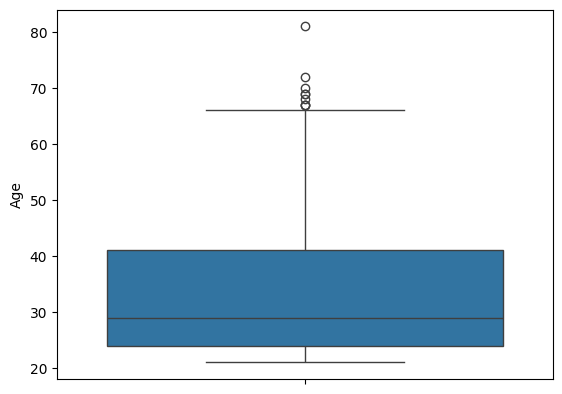

In [64]:
sns.boxplot(df['Age'])

In [65]:
# IMputation by Median
def impute_outliers(feature):
    q1 = feature.quantile(0.25)
    q2 = feature.quantile(0.5)
    q3 = feature.quantile(0.75)
    
    print('Q1 == ', q1)
    print('Q2 == ', q2)
    print('Q3 == ', q3)
    
    iqr = q3 - q1
    print('IQR == ', iqr)
    
    upper_tail = q3 + 1.5* iqr
    lower_tail = q1 - 1.5* iqr
    
    print('Upper Tail == ', upper_tail)
    print('Lower Tail == ', lower_tail)

    feature.loc[feature > upper_tail] = q2
    feature.loc[feature < lower_tail] = q2

impute_outliers(df1['Age'])

Q1 ==  24.0
Q2 ==  29.0
Q3 ==  41.0
IQR ==  17.0
Upper Tail ==  66.5
Lower Tail ==  -1.5


<Axes: ylabel='Age'>

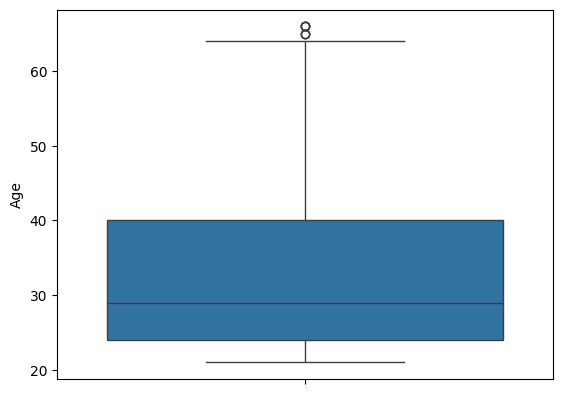

In [66]:
sns.boxplot(df1['Age'])

In [67]:
df1 = df.copy()

In [68]:
# IMputation by lowe and upper tail
def impute_outliers(feature):
    q1 = feature.quantile(0.25)
    q2 = feature.quantile(0.5)
    q3 = feature.quantile(0.75)
    
    print('Q1 == ', q1)
    print('Q2 == ', q2)
    print('Q3 == ', q3)
    
    iqr = q3 - q1
    print('IQR == ', iqr)
    
    upper_tail = q3 + 1.5* iqr
    lower_tail = q1 - 1.5* iqr
    
    print('Upper Tail == ', upper_tail)
    print('Lower Tail == ', lower_tail)

    feature.loc[feature > upper_tail] = upper_tail
    feature.loc[feature < lower_tail] = lower_tail

impute_outliers(df1['Age'])

Q1 ==  24.0
Q2 ==  29.0
Q3 ==  41.0
IQR ==  17.0
Upper Tail ==  66.5
Lower Tail ==  -1.5


In [69]:
df1[df1['Age'] > upper_tail]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [70]:
# IMputation by lowe and upper tail
def impute_outliers(feature):
    q1 = feature.quantile(0.25)
    q2 = feature.quantile(0.5)
    q3 = feature.quantile(0.75)
    
    print('Q1 == ', q1)
    print('Q2 == ', q2)
    print('Q3 == ', q3)
    
    iqr = q3 - q1
    print('IQR == ', iqr)
    
    upper_tail = q3 + 1.5* iqr
    lower_tail = q1 - 1.5* iqr
    
    print('Upper Tail == ', upper_tail)
    print('Lower Tail == ', lower_tail)

    # feature.loc[feature > upper_tail] = upper_tail
    # feature.loc[feature < lower_tail] = lower_tail
    return upper_tail, lower_tail

upper_tail, lower_tail = impute_outliers(df1['Age'])

Q1 ==  24.0
Q2 ==  29.0
Q3 ==  41.0
IQR ==  17.0
Upper Tail ==  66.5
Lower Tail ==  -1.5


In [72]:
df1 = df.copy()

In [73]:
df1['Age'] = np.where(df1['Age'] > upper_tail, upper_tail,
                     np.where(df1['Age']< lower_tail, lower_tail, df1['Age']))

<Axes: ylabel='Age'>

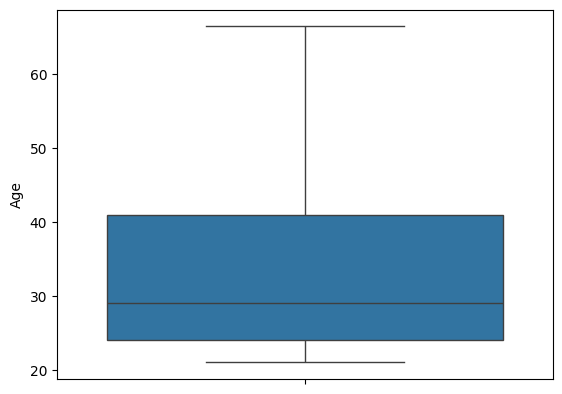

In [74]:
sns.boxplot(df1['Age'])

### Transformations

It is used to handle skewness of data

It is also used to reduce the  impact of the outliers

##### 1. Log transformation 

Natural Log >> np.log

In [75]:
x = 1
print(np.log(x))
print(np.log2(x))
print(np.log10(x))

0.0
0.0
0.0


In [76]:
x = 0
print(np.log(x))
print(np.log2(x))
print(np.log10(x))

-inf
-inf
-inf


In [77]:
x = -10
print(np.log(x))
print(np.log2(x))
print(np.log10(x))

nan
nan
nan


In [78]:
x = 2
print(np.log(x))
print(np.log2(x))
print(np.log10(x))

0.6931471805599453
1.0
0.3010299956639812


<Axes: xlabel='Age', ylabel='Density'>

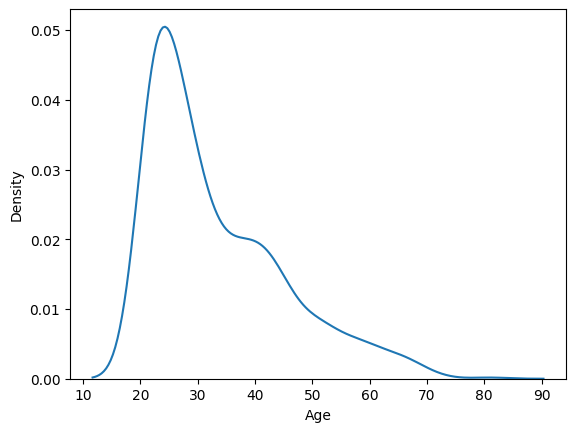

In [79]:
sns.kdeplot(df['Age'])

In [ ]:
# df['Age'] = np.log(df['Age'])

<Axes: xlabel='Age', ylabel='Density'>

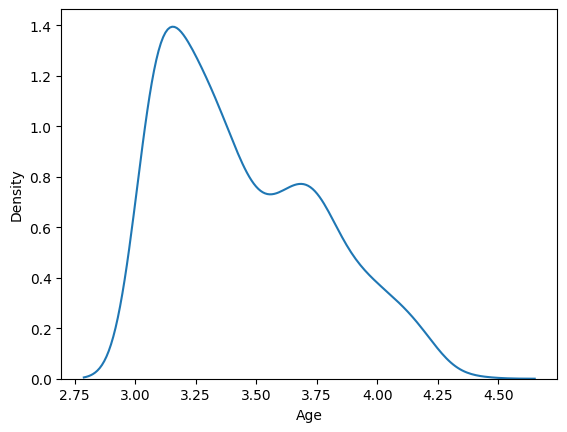

In [80]:
sns.kdeplot(np.log(df['Age']))

<Axes: ylabel='Age'>

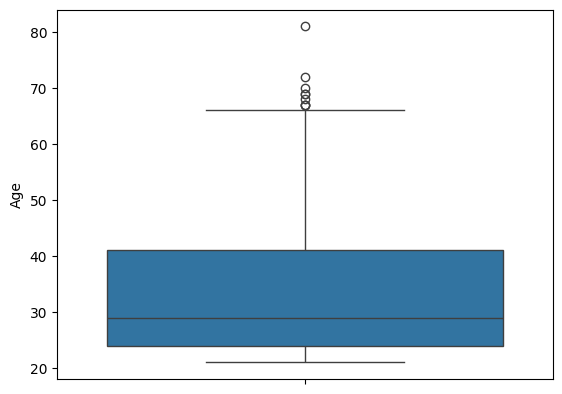

In [81]:
sns.boxplot(df['Age'])

<Axes: ylabel='Age'>

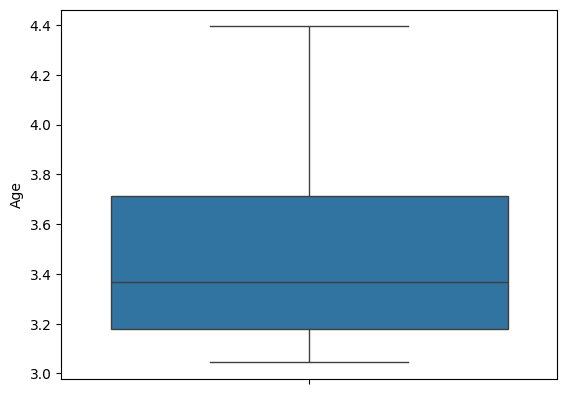

In [82]:
sns.boxplot(np.log(df['Age']))

<Axes: ylabel='Insulin'>

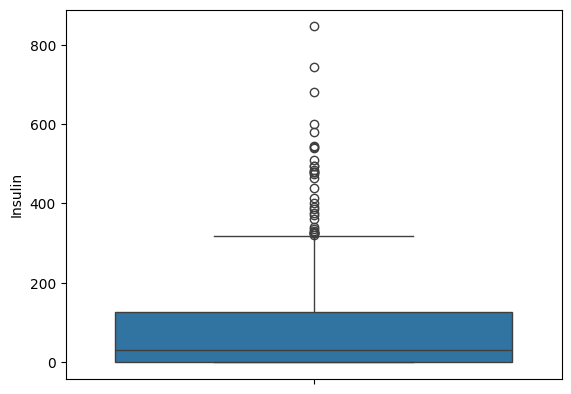

In [83]:
sns.boxplot((df['Insulin']))

<Axes: ylabel='Insulin'>

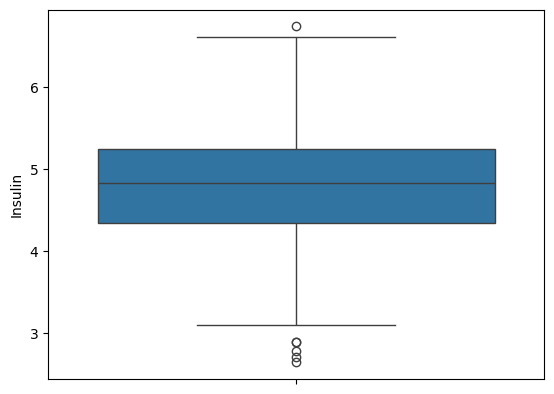

In [84]:
sns.boxplot(np.log(df['Insulin']))

<Axes: xlabel='Insulin', ylabel='Density'>

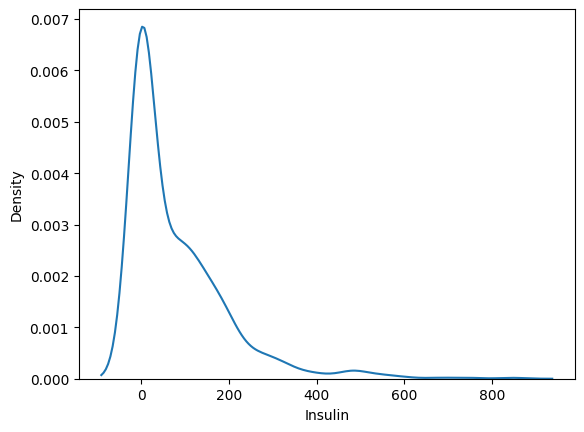

In [85]:
sns.kdeplot(df['Insulin'])

<Axes: xlabel='Insulin', ylabel='Density'>

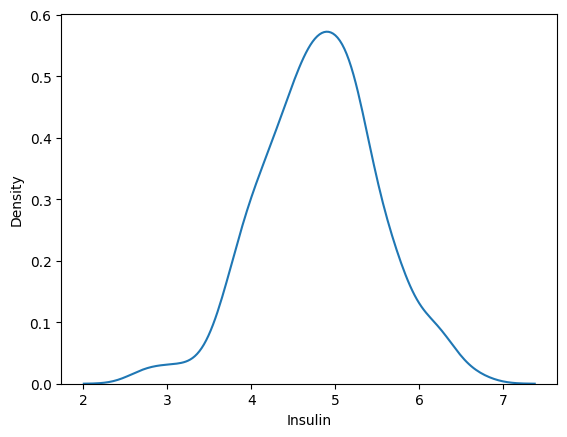

In [86]:
sns.kdeplot(np.log(df['Insulin']))

In [87]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [90]:
# dir(housing_df)

In [91]:
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
# housing_df['Target'] = housing_df.target
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


<Axes: >

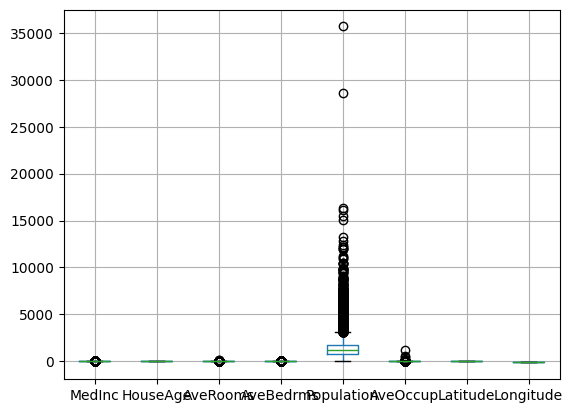

In [92]:
housing_df.boxplot()

<Axes: >

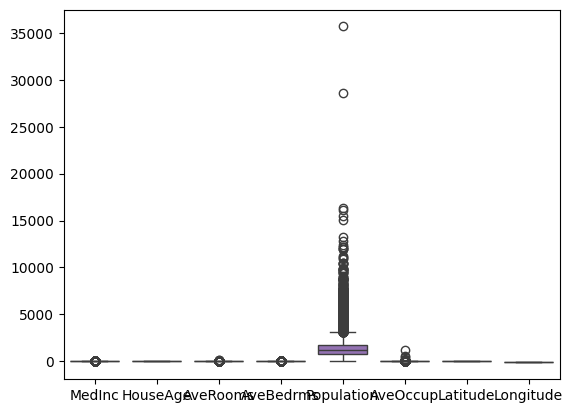

In [93]:
sns.boxplot(housing_df)

In [94]:
housing_df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

<Axes: xlabel='HouseAge', ylabel='Density'>

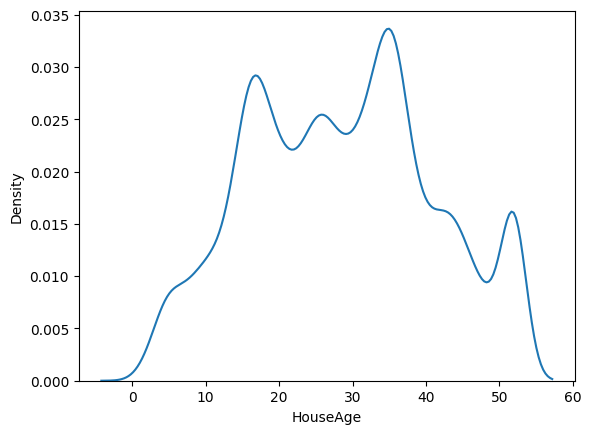

In [95]:
sns.kdeplot(housing_df['HouseAge'])

In [97]:
# from sklearn.datasets import load_boston

In [98]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [99]:
boston_df = raw_df.dropna()
boston_df.columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO']
boston_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
2,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
4,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8
6,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7
8,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7
...,...,...,...,...,...,...,...,...,...,...,...
1002,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0
1004,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0
1006,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0
1008,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0


<Axes: >

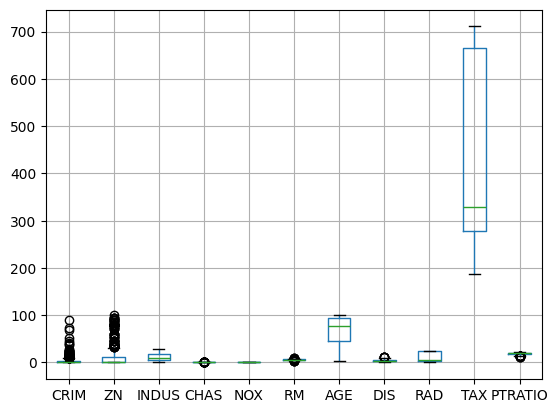

In [100]:
boston_df.boxplot()

<Axes: ylabel='DIS'>

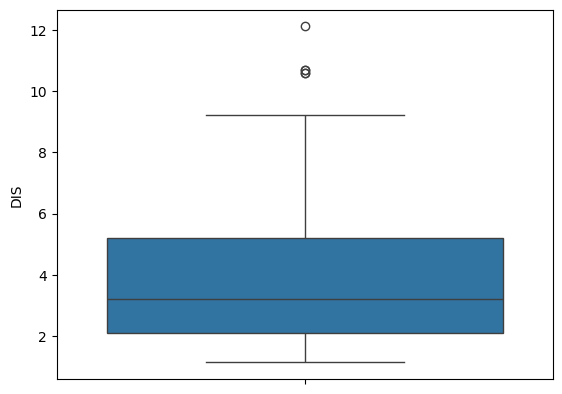

In [101]:
sns.boxplot(boston_df['DIS'])

<Axes: ylabel='DIS'>

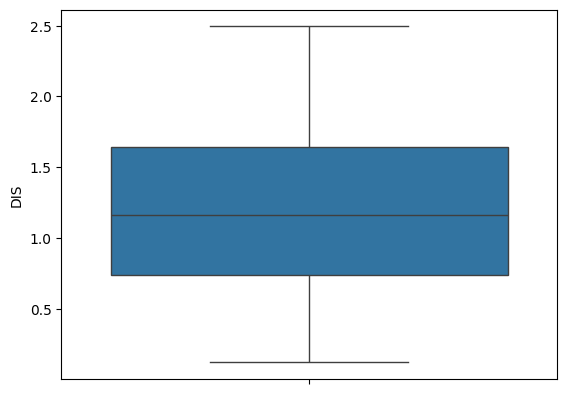

In [102]:
sns.boxplot(np.log(boston_df['DIS']))

<Axes: ylabel='ZN'>

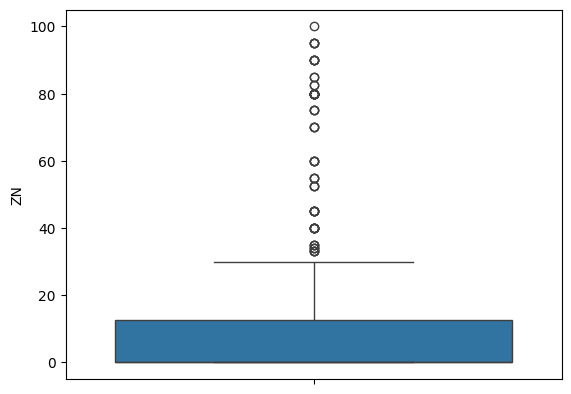

In [103]:
sns.boxplot(boston_df['ZN'])

<Axes: ylabel='ZN'>

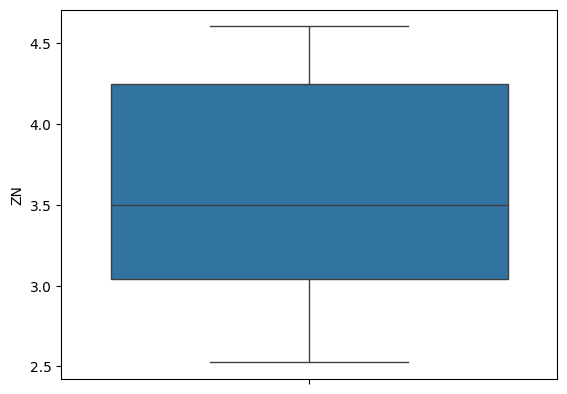

In [104]:
sns.boxplot(np.log(boston_df['ZN']))

<Axes: ylabel='Population'>

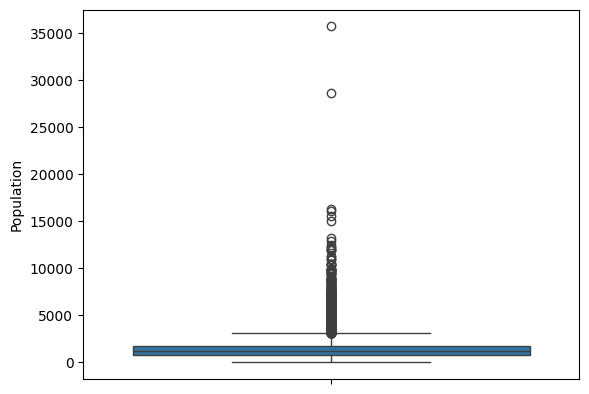

In [105]:
sns.boxplot(housing_df['Population'])

<Axes: ylabel='Population'>

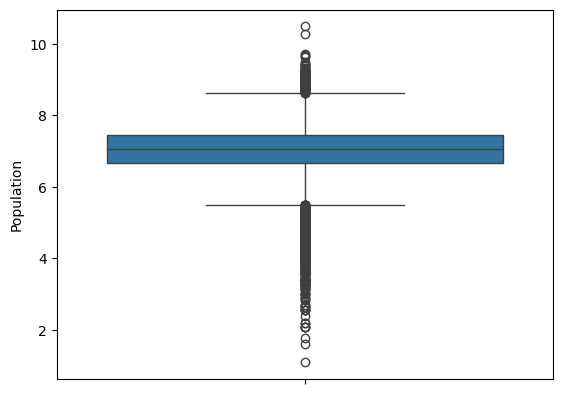

In [106]:
sns.boxplot(np.log(housing_df['Population']))

#### Square root

<Axes: ylabel='DIS'>

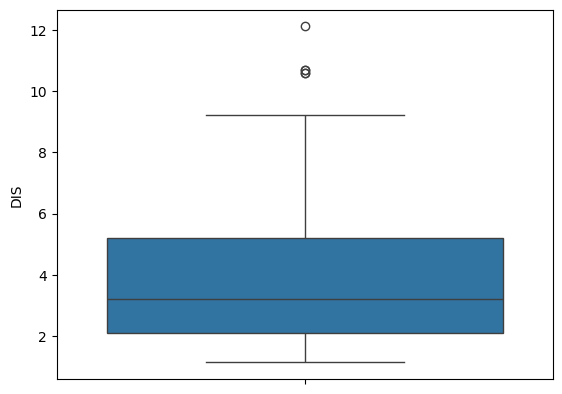

In [107]:
sns.boxplot(boston_df['DIS'])

<Axes: ylabel='DIS'>

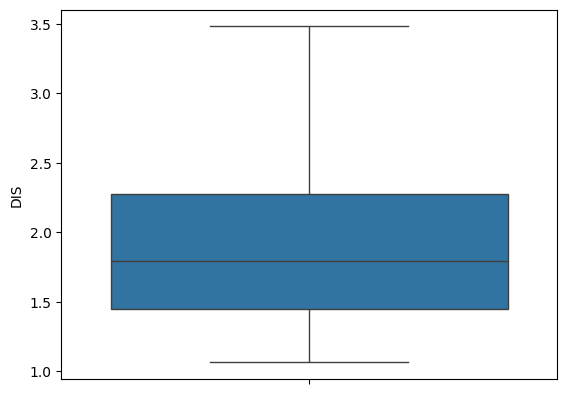

In [108]:
sns.boxplot(np.sqrt(boston_df['DIS']))

<Axes: ylabel='Population'>

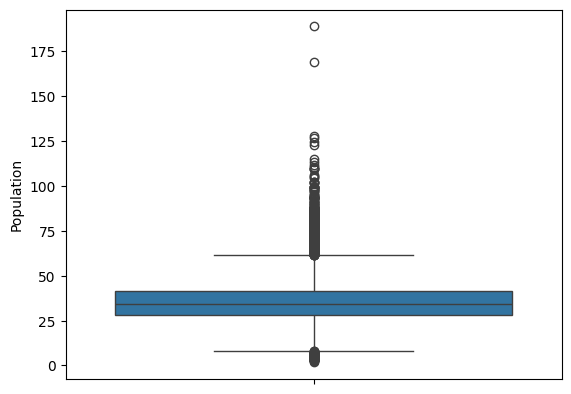

In [109]:
sns.boxplot(np.sqrt(housing_df['Population']))

#### 3. Cube root

<Axes: ylabel='Population'>

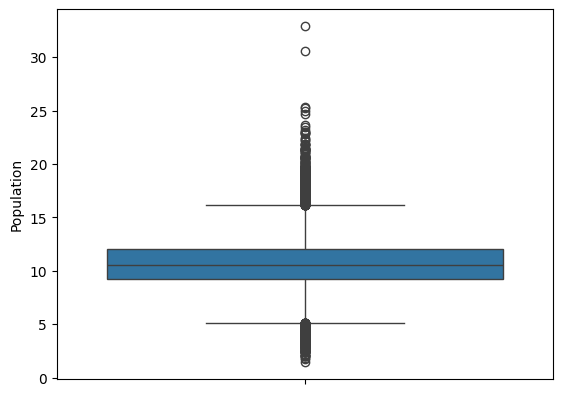

In [110]:
sns.boxplot(np.cbrt(housing_df['Population']))